<a href="https://colab.research.google.com/github/AngryWeassel/Proyecto_Tasa_de_Natalidad.ipynb/blob/main/Proyecto_Tasa_de_Natalidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [94]:
import gdown
import pandas as pd
import matplotlib.pyplot as plt

#Importación de lista de Paises de la OECD
#Fuente: Consulta en Google y creación de Excel manual
archivo_nombres_oecd = 'https://docs.google.com/spreadsheets/d/1gpatuWv1C5Iq14sTngbqZV01PtK4T-1VuIty43tDE58/edit?usp=drive_link'
nombres_oecd = gdown.download(archivo_nombres_oecd, quiet=True, fuzzy=True)
oecd = pd.read_excel(nombres_oecd)

#Importación de datos del PIB(en ingles GDP) de los paises a nivel global
#Fuente:
archivo_gdp = 'https://drive.google.com/file/d/1RWhkgYFs73Ya0XUdyNmeo8IZ7yLC7mxG/view?usp=sharing'
gpd = gdown.download(archivo_gdp, quiet=True, fuzzy=True)
datos_gdp = pd.read_csv(gpd)

In [95]:
diccionario_paises = {
    'Alemania': 'Germany',
    'Australia': 'Australia',
    'Austria': 'Austria',
    'Bélgica': 'Belgium',
    'Canadá': 'Canada',
    'Chile': 'Chile',
    'Colombia': 'Colombia',
    'Corea del Sur': 'South Korea',
    'Costa Rica': 'Costa Rica',
    'Dinamarca': 'Denmark',
    'Eslovenia': 'Slovenia',
    'España': 'Spain',
    'Estados Unidos': 'United States',
    'Estonia': 'Estonia',
    'Finlandia': 'Finland',
    'Francia': 'France',
    'Grecia': 'Greece',
    'Hungría': 'Hungary',
    'Irlanda': 'Ireland',
    'Islandia': 'Iceland',
    'Israel': 'Israel',
    'Italia': 'Italy',
    'Japón': 'Japan',
    'Letonia': 'Latvia',
    'Lituania': 'Lithuania',
    'Luxemburgo': 'Luxembourg',
    'México': 'Mexico',
    'Noruega': 'Norway',
    'Nueva Zelanda': 'New Zealand',
    'Países Bajos': 'Netherlands',
    'Polonia': 'Poland',
    'Portugal': 'Portugal',
    'Reino Unido': 'United Kingdom',
    'República Checa': 'Czechia',
    'República Eslovaca': 'Slovakia',
    'Suecia': 'Sweden',
    'Suiza': 'Switzerland',
    'Turquía': 'Turkey'
}
oecd['OECD Countries'] = oecd['Paises OCDE'].map(diccionario_paises)
inv_diccionario_paises = {v: k for k, v in diccionario_paises.items()}


In [96]:
oecd_list = oecd['OECD Countries'].tolist()

gdp_oecd = datos_gdp[
    (datos_gdp['Entity'].isin(oecd_list)) &
    (datos_gdp['Year'] >= 2014) &
    (datos_gdp['Year'] <= 2024)
]

In [103]:
gdp_oecd['Pais'] = gdp_oecd['Entity'].map(inv_diccionario_paises)

/tmp/ipykernel_5872/3127508655.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gdp_oecd['Pais'] = gdp_oecd['Entity'].map(inv_diccionario_paises)


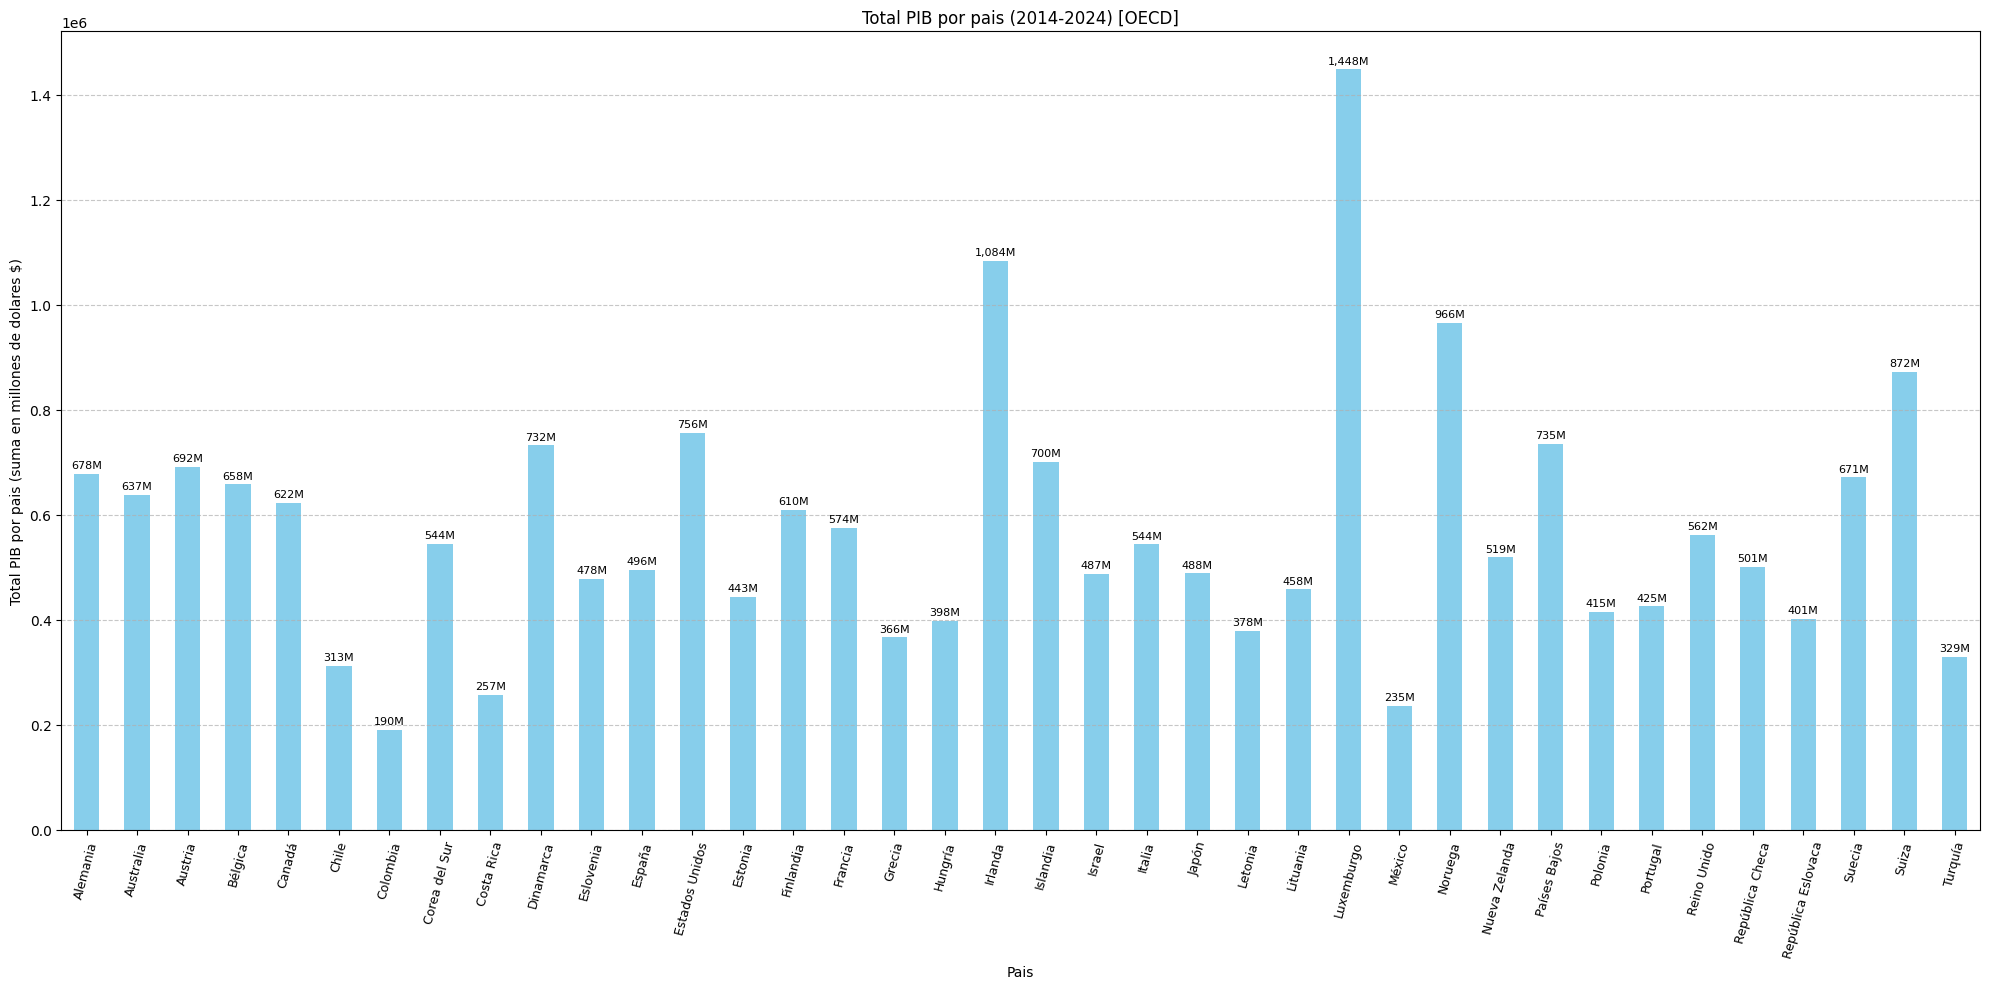

In [100]:
pais_gdp_sum = gdp_oecd.groupby('Pais')['GDP per capita'].sum()
plt.figure(figsize=(20, 10))
pais_gdp_sum.plot(kind='bar', color='skyblue')
plt.title('Total PIB por pais (2014-2024) [OECD]')
plt.xlabel('Pais')
plt.ylabel('Total PIB por pais (suma en millones de dolares $)')
plt.xticks(rotation=75, fontsize=9)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate bars with their values
for index, value in enumerate(pais_gdp_sum):
    plt.text(index, value + (max(entity_gdp_sum) * 0.005), f'{value/1000:,.0f}M', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()